# Chương 2: Không gian trạng thái & Tìm kiếm mù – Bài thực hành Python   
Google Colab Notebook  

**Mục tiêu:**  
* Hiểu khái niệm không gian trạng thái.  
* Cài đặt & trực quan hóa các chiến lược tìm kiếm mù:  
  * Tìm kiếm theo bề rộng (Breadth‑First Search – BFS)  
  * Tìm kiếm theo chiều sâu (Depth‑First Search – DFS)  
  * Tìm kiếm với độ sâu giới hạn (Depth‑Limited Search – DLS)  
  * Tìm kiếm với độ sâu lặp (Iterative Deepening Search – IDS)  
* Minh hoạ khái niệm *chia để trị* (divide & conquer) bằng ví dụ sắp xếp.  
* Xây dựng & khám phá **đồ thị VÀ/HOẶC** (AND/OR graph).  

> **Hướng dẫn:** Chạy lần lượt từng ô (Shift + Enter). Hãy đọc kỹ phần mô tả trước khi điều chỉnh mã nguồn và thử nghiệm.


## 2.1 Khái niệm về không gian trạng thái  

*Không gian trạng thái* của một bài toán bao gồm:  

* **Trạng thái khởi đầu** (`initial_state`)  
* **Tập hành động hợp lệ** chuyển từ trạng thái hiện tại sang các trạng thái mới (`actions`)  
* **Hàm kế thừa** (`successor(state, action)`) tạo ra trạng thái kế tiếp  
* **Điều kiện đích** (`goal_test(state)`) xác định khi nào thuật toán dừng.  

Trong bài thực hành này, ta mô hình hoá một **đồ thị** vô hướng nhỏ để dễ quan sát.


In [ ]:
!apt-get -qq install -y graphviz libgraphviz-dev
!pip install -q pygraphviz
!pip install networkx matplotlib

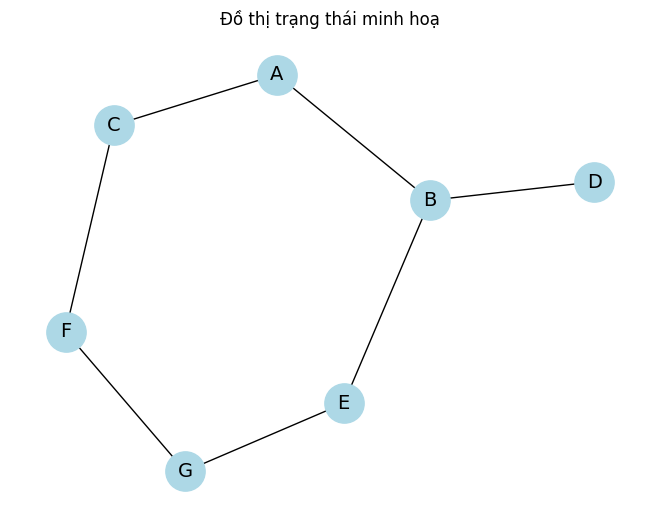

Trạng thái khởi đầu: A  →  Đích: G


In [ ]:
#@title Khởi tạo đồ thị ví dụ
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
edges = [("A","B"),("A","C"),("B","D"),("B","E"),("C","F"),("E","G"),("F","G")]
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=14)
plt.title("Đồ thị trạng thái minh hoạ"); plt.show()

initial_state = "A"
goal_state    = "G"
print(f"Trạng thái khởi đầu: {initial_state}  →  Đích: {goal_state}")

## 2.2 Chiến lược tìm kiếm theo bề rộng (Breadth‑First Search – BFS)  

Ý tưởng: mở rộng các nút theo từng **tầng**; luôn khám phá các trạng thái ở độ sâu nhỏ nhất chưa được thăm.

In [ ]:
from collections import deque

def bfs(graph, start, goal):
    frontier = deque([start])
    explored = set([start])
    parent   = {start: None}
    while frontier:
        current = frontier.popleft()
        if current == goal:
            # reconstruct path
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1]
        for neighbor in graph.neighbors(current):
            if neighbor not in explored:
                explored.add(neighbor)
                parent[neighbor] = current
                frontier.append(neighbor)
    return None

path_bfs = bfs(G, initial_state, goal_state)
print("Đường đi (BFS):", path_bfs)

Đường đi (BFS): ['A', 'B', 'E', 'G']


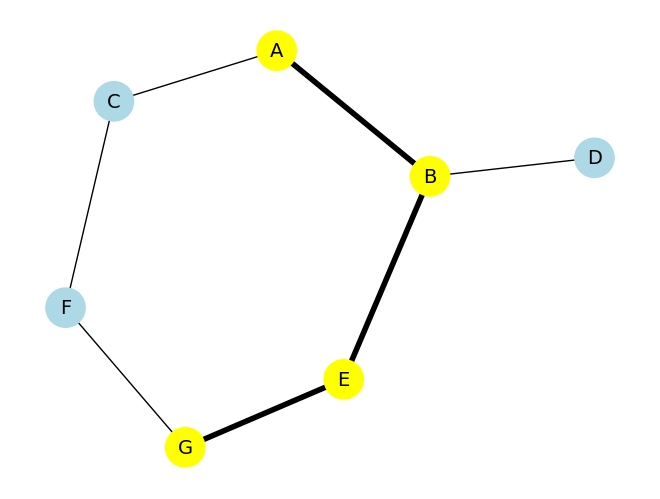

In [ ]:
#@title Trực quan hoá BFS
def draw_path(path, graph=G, pos=None):
    if pos is None:
        pos = nx.spring_layout(graph, seed=42)
    colors = ['lightblue' if n not in path else 'yellow' for n in graph.nodes]
    nx.draw(graph, pos, with_labels=True, node_color=colors, node_size=800, font_size=14)
    # highlight edges in path
    if path:
        edge_list = list(zip(path, path[1:]))
        nx.draw_networkx_edges(graph, pos, edgelist=edge_list, width=4)
    plt.show()

draw_path(path_bfs)

## 2.3 Chiến lược tìm kiếm theo chiều sâu (Depth‑First Search – DFS)  

DFS mở rộng nút sâu nhất trong cây tìm kiếm trước tiên, có thể dẫn tới **lối đi sâu** và hao tốn thời gian ở những nhánh không đích.

Đường đi (DFS): ['A', 'B', 'E', 'G']


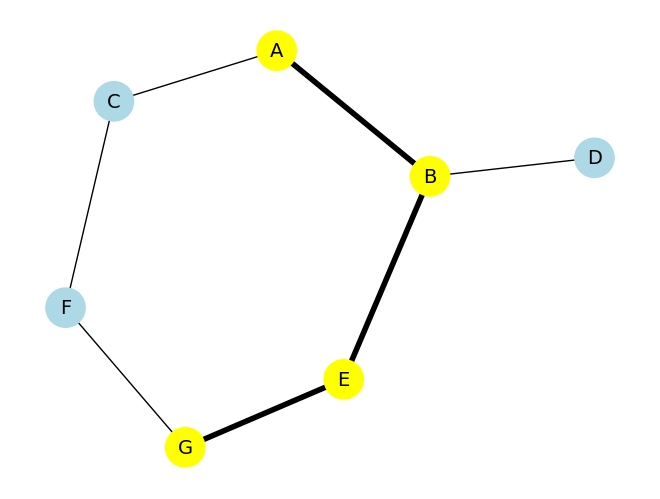

In [ ]:
def dfs(graph, start, goal):
    stack   = [start]
    explored= set([start])
    parent  = {start: None}
    while stack:
        current = stack.pop()
        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1]
        for neighbor in reversed(list(graph.neighbors(current))):  # đảo để giống BFS khi hiển thị
            if neighbor not in explored:
                explored.add(neighbor)
                parent[neighbor] = current
                stack.append(neighbor)
    return None

path_dfs = dfs(G, initial_state, goal_state)
print("Đường đi (DFS):", path_dfs)
draw_path(path_dfs)

## 2.4 Chiến lược tìm kiếm với độ sâu giới hạn (Depth‑Limited Search – DLS)  

DFS kèm **ngưỡng độ sâu `limit`** nhằm tránh đi quá sâu vào cây tìm kiếm.

Đường đi (DLS, limit=3): ['A', 'B', 'E', 'G']


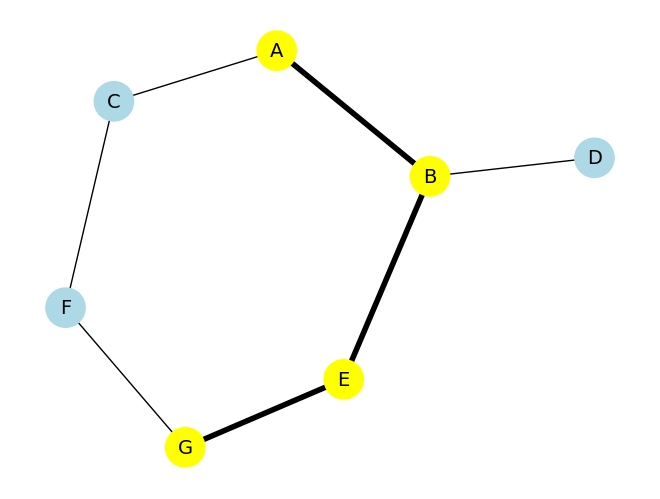

In [ ]:
def dls(graph, start, goal, limit):
    def recursive(node, depth):
        if node == goal:
            return [node]
        if depth == 0:
            return None
        for neighbor in graph.neighbors(node):
            res = recursive(neighbor, depth-1)
            if res:
                return [node] + res
        return None
    return recursive(start, limit)

path_dls = dls(G, initial_state, goal_state, limit=3)
if path_dls:
    print("Đường đi (DLS, limit=3):", path_dls)
    draw_path(path_dls)
else:
  print("Không tìm thấy đường đi")

## 2.5 Chiến lược tìm kiếm với độ sâu lặp (Iterative Deepening Search – IDS)  

Kết hợp **bao quát** của BFS và **tiết kiệm bộ nhớ** của DFS – tăng dần `limit` cho đến khi tìm thấy đích.

IDS tìm thấy ở depth=3: ['A', 'B', 'E', 'G']


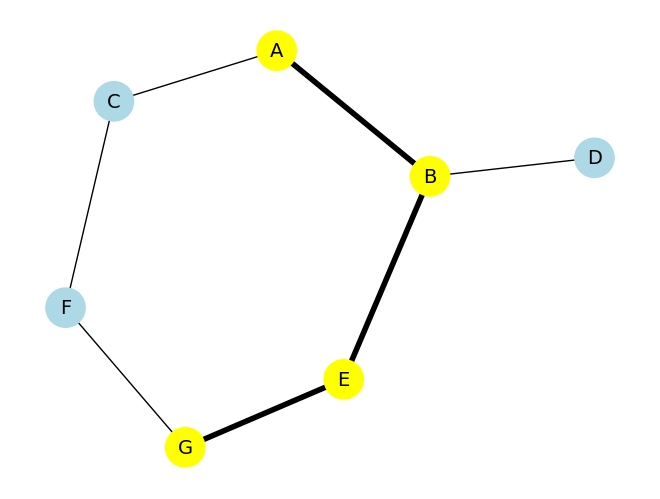

In [ ]:
def ids(graph, start, goal, max_depth=10):
    for depth in range(max_depth+1):
        path = dls(graph, start, goal, depth)
        if path:
            return path, depth
    return None, None

path_ids, depth_found = ids(G, initial_state, goal_state, max_depth=10)
print(f"IDS tìm thấy ở depth={depth_found}: {path_ids}")
draw_path(path_ids)

## 2.6 Chia để trị (Divide & Conquer)  

Ví dụ điển hình: **QuickSort**. Hàm sau minh hoạ cách chia mảng, đệ quy sắp xếp hai phần nhỏ hơn.

In [ ]:
def quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr)//2]
    left  = [x for x in arr if x < pivot]
    equal = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quicksort(left) + equal + quicksort(right)

sample = [7,3,5,2,9,1,4]
print("Trước:", sample)
print("Sau   :", quicksort(sample))

Trước: [7, 3, 5, 2, 9, 1, 4]
Sau   : [1, 2, 3, 4, 5, 7, 9]


## 2.7 Xây dựng đồ thị **VÀ/HOẶC** (AND/OR graph)  

Một **nút VÀ** chỉ thành công khi *tất cả* con của nó thành công;  
một **nút HOẶC** thành công nếu *ít nhất một* con thành công.

Ví dụ sau minh hoạ cây nhiệm vụ nhỏ (task decomposition).

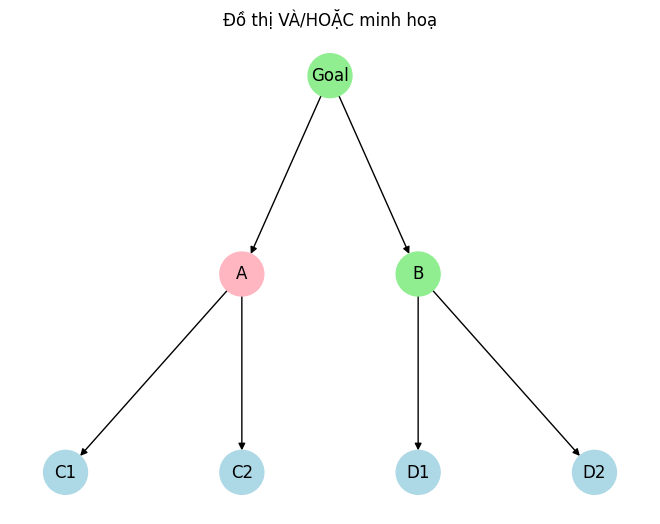

In [ ]:
#@title Định nghĩa & trực quan hoá AND/OR graph
import itertools

AOG = nx.DiGraph()
# Đặt thuộc tính 'type': 'AND' hoặc 'OR'
AOG.add_node("Goal", type="AND")
AOG.add_node("A", type="OR")
AOG.add_node("B", type="AND")
AOG.add_node("C1", type="leaf")
AOG.add_node("C2", type="leaf")
AOG.add_node("D1", type="leaf")
AOG.add_node("D2", type="leaf")

AOG.add_edges_from([("Goal","A"),("Goal","B"),
                    ("A","C1"),("A","C2"),
                    ("B","D1"),("B","D2")])

pos = nx.nx_agraph.graphviz_layout(AOG, prog="dot")
colors = []
for n in AOG.nodes:
    t = AOG.nodes[n].get("type","leaf")
    colors.append({"AND":"lightgreen","OR":"lightpink","leaf":"lightblue"}[t])
nx.draw(AOG, pos, with_labels=True, node_color=colors, node_size=1000, font_size=12)
plt.title("Đồ thị VÀ/HOẶC minh hoạ")
plt.show()

### Hàm đánh giá trạng thái (giả lập)  

Trong đồ thị trên, giả sử nút lá *thành công* với xác suất ngẫu nhiên. Hãy hoàn thành hàm `evaluate(node)` để mô phỏng quá trình duyệt AND/OR graph.

In [ ]:
import random

def evaluate(node, graph=AOG):
    t = graph.nodes[node].get("type","leaf")
    if t == "leaf":
        return random.random() < 0.7   # 70% thành công
    elif t == "AND":
        return all(evaluate(c) for c in graph.successors(node))
    elif t == "OR":
        return any(evaluate(c) for c in graph.successors(node))

print("Kết quả giả lập:", evaluate("Goal"))

Kết quả giả lập: False


---  
### Tóm tắt  

* Đã cài đặt & so sánh các chiến lược tìm kiếm mù.  
* Hiểu bản chất DFS, BFS, DLS, IDS qua ví dụ nhỏ & đồ thị.  
* Nhận diện khái niệm *chia để trị* qua QuickSort.  
* Khám phá cấu trúc AND/OR graph và cách đánh giá.  



# **Bài tập:**  

Bài 1. Thay đồ thị ví dụ bằng bài toán 8‑Puzzle hoặc Đường đi trong mê cung.  

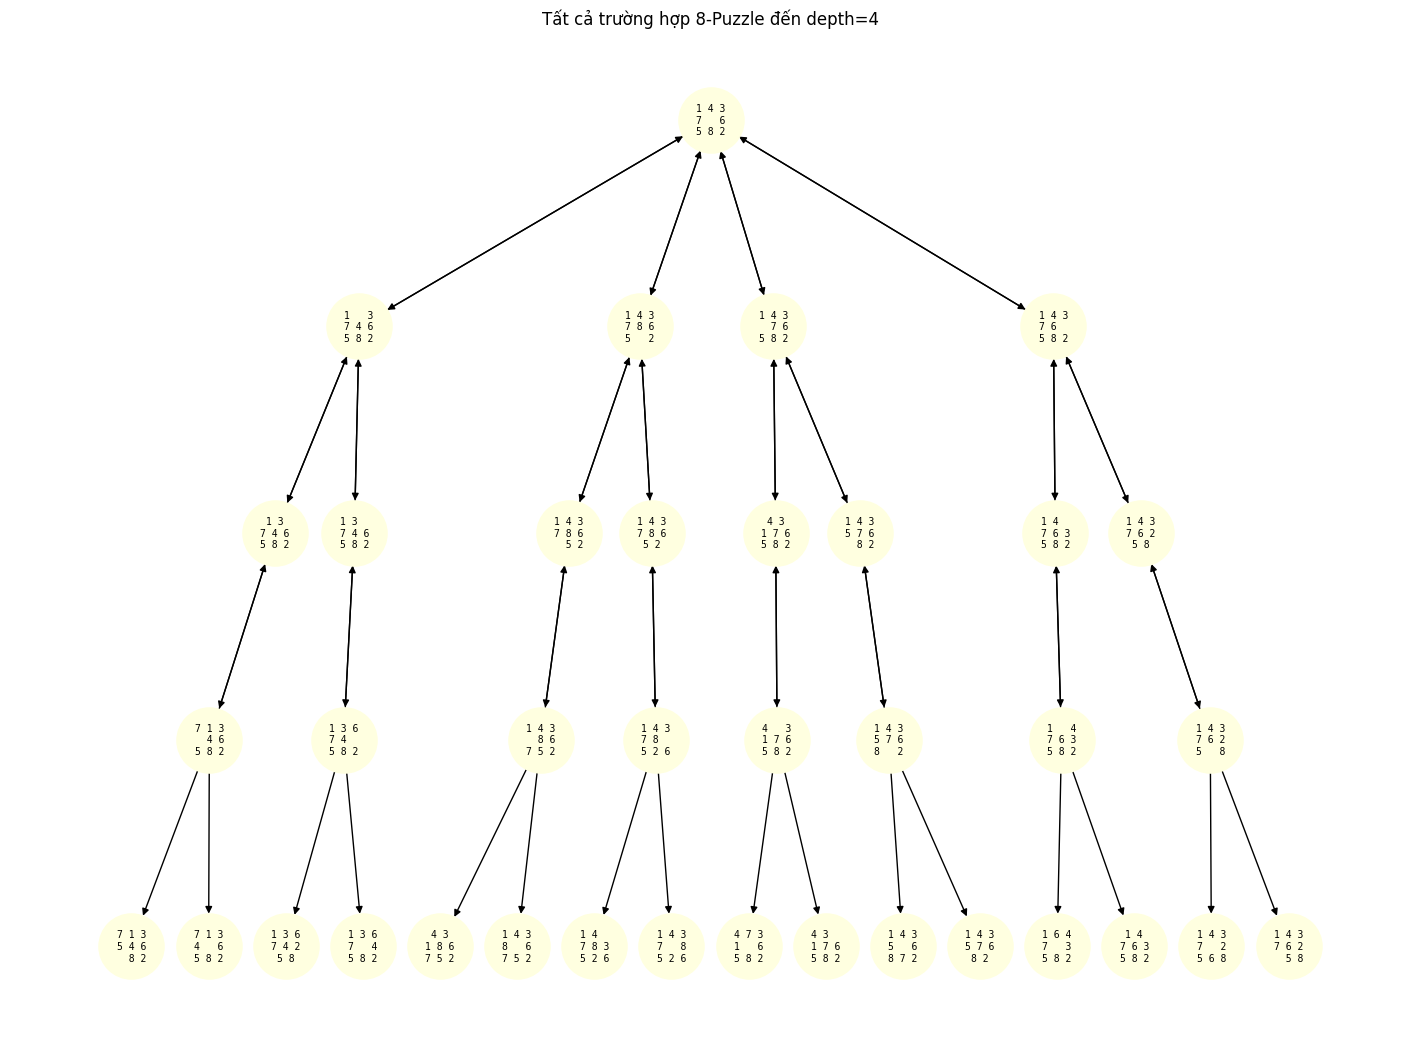

Số node: 37
Số cạnh: 56


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

initial_state = (1,4,3,
                 7,0,6,
                 5,8,2)

def get_neighbors(state):
    neighbors = {}
    idx = state.index(0)
    row, col = divmod(idx, 3)
    moves = {"Up":(-1,0), "Down":(1,0), "Left":(0,-1), "Right":(0,1)}
    for move,(dr,dc) in moves.items():
        r, c = row+dr, col+dc
        if 0 <= r < 3 and 0 <= c < 3:
            new_idx = r*3+c
            new_state = list(state)
            new_state[idx], new_state[new_idx] = new_state[new_idx], new_state[idx]
            neighbors[move] = tuple(new_state)
    return neighbors

def format_state(state):
    s = ""
    for i in range(0,9,3):
        row = [" " if x==0 else str(x) for x in state[i:i+3]]
        s += " ".join(row) + "\n"
    return s.strip()

# Sinh toàn bộ cây đến depth N
depth_limit = 4
G = nx.DiGraph()
G.add_node(initial_state)

frontier = [(initial_state, 0)]
visited = set([initial_state])

while frontier:
    state, depth = frontier.pop(0)
    if depth < depth_limit:
        for move, nxt in get_neighbors(state).items():
            if nxt not in visited:
                visited.add(nxt)
                G.add_node(nxt)
            G.add_edge(state, nxt, label=move)
            frontier.append((nxt, depth+1))

# Vẽ cây
pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
plt.figure(figsize=(14,10))
nx.draw(G, pos, with_labels=False, node_color="lightyellow", node_size=2200)

labels = {n: format_state(n) for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_family="monospace")

plt.title(f"Tất cả trường hợp 8-Puzzle đến depth={depth_limit}")
plt.axis("off")
plt.show()

print("Số node:", len(G.nodes))
print("Số cạnh:", len(G.edges))

Bài 2. Đếm số nút đã mở rộng cho từng chiến lược & vẽ biểu đồ so sánh.  

Số nút đã mở rộng:
BFS: 181440
DFS: 67087
UCS: 241921
A*: 241921


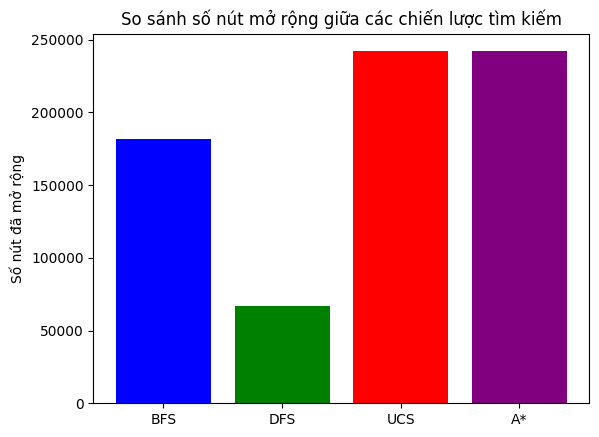

In [13]:
import heapq
import matplotlib.pyplot as plt
from collections import deque

# Định nghĩa trạng thái đích
goal_state = (1,2,3,4,5,6,7,8,0)

# Lấy các trạng thái con
def get_neighbors(state):
    neighbors = []
    idx = state.index(0)
    x, y = divmod(idx, 3)
    moves = [(-1,0),(1,0),(0,-1),(0,1)]  # lên, xuống, trái, phải
    for dx, dy in moves:
        nx, ny = x+dx, y+dy
        if 0 <= nx < 3 and 0 <= ny < 3:
            nidx = nx*3 + ny
            new_state = list(state)
            new_state[idx], new_state[nidx] = new_state[nidx], new_state[idx]
            neighbors.append(tuple(new_state))
    return neighbors

# Hàm heuristic cho A* (sai lệch Manhattan)
def manhattan(state):
    dist = 0
    for i, v in enumerate(state):
        if v != 0:
            x, y = divmod(i, 3)
            gx, gy = divmod(v-1, 3)
            dist += abs(x-gx) + abs(y-gy)
    return dist

# BFS
def bfs(start):
    frontier = deque([start])
    explored = set()
    expanded = 0
    while frontier:
        state = frontier.popleft()
        expanded += 1
        if state == goal_state:
            return expanded
        explored.add(state)
        for nxt in get_neighbors(state):
            if nxt not in explored and nxt not in frontier:
                frontier.append(nxt)
    return expanded

# DFS (giới hạn độ sâu để tránh vòng lặp vô tận)
def dfs(start, depth_limit=20):
    frontier = [(start,0)]
    explored = set()
    expanded = 0
    while frontier:
        state, depth = frontier.pop()
        expanded += 1
        if state == goal_state:
            return expanded
        if depth < depth_limit:
            explored.add(state)
            for nxt in get_neighbors(state):
                if nxt not in explored:
                    frontier.append((nxt, depth+1))
    return expanded

# Uniform Cost Search
def ucs(start):
    frontier = [(0, start)]
    explored = set()
    expanded = 0
    while frontier:
        cost, state = heapq.heappop(frontier)
        expanded += 1
        if state == goal_state:
            return expanded
        if state in explored:
            continue
        explored.add(state)
        for nxt in get_neighbors(state):
            if nxt not in explored:
                heapq.heappush(frontier, (cost+1, nxt))
    return expanded

# A*
def astar(start):
    frontier = [(manhattan(start), 0, start)]
    explored = set()
    expanded = 0
    while frontier:
        f, g, state = heapq.heappop(frontier)
        expanded += 1
        if state == goal_state:
            return expanded
        if state in explored:
            continue
        explored.add(state)
        for nxt in get_neighbors(state):
            if nxt not in explored:
                heapq.heappush(frontier, (g+1+manhattan(nxt), g+1, nxt))
    return expanded

# --------- CHẠY THỬ ------------
start_state = (1,3,4,7,0,6,5,8,2)   # trạng thái ban đầu từ hình bạn gửi

results = {}
results["BFS"] = bfs(start_state)
results["DFS"] = dfs(start_state, depth_limit=30)
results["UCS"] = ucs(start_state)
results["A*"]  = astar(start_state)

print("Số nút đã mở rộng:")
for k,v in results.items():
    print(f"{k}: {v}")

# --------- VẼ BIỂU ĐỒ ------------
plt.bar(results.keys(), results.values(), color=["blue","green","red","purple"])
plt.ylabel("Số nút đã mở rộng")
plt.title("So sánh số nút mở rộng giữa các chiến lược tìm kiếm")
plt.show()


Bài 3. Thay `evaluate()` bằng hàm tính chi phí & tìm phương án tối ưu trong AND/OR graph.

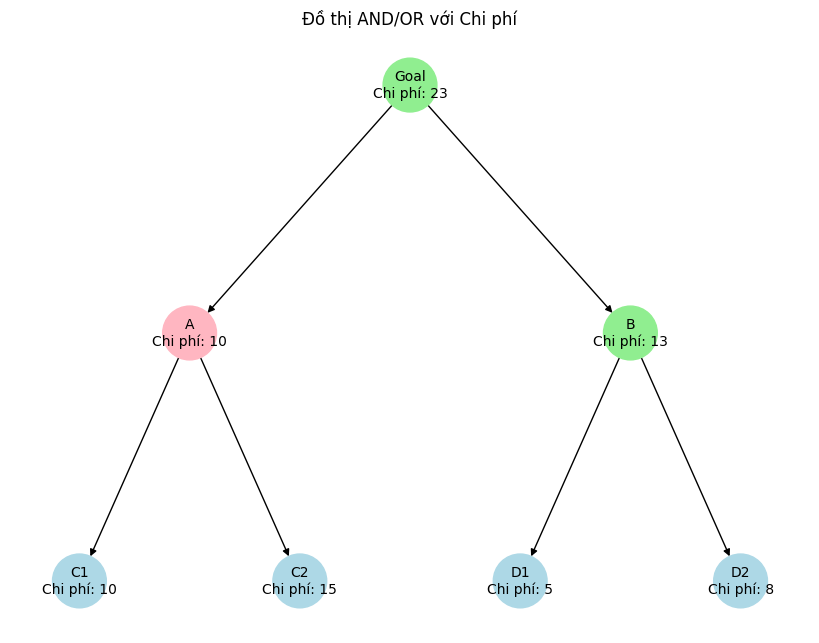

Chi phí tối ưu: 23
Phương án tối ưu: ['C1', 'D1', 'D2']


In [23]:
import networkx as nx
import matplotlib.pyplot as plt

# Khởi tạo đồ thị AND/OR
AOG = nx.DiGraph()
AOG.add_node("Goal", type="AND")  # Nút gốc là nút AND
AOG.add_node("A", type="OR")      # Nút OR
AOG.add_node("B", type="AND")     # Nút AND
AOG.add_node("C1", type="leaf", cost=10)  # Nút lá với chi phí 10
AOG.add_node("C2", type="leaf", cost=15)  # Nút lá với chi phí 15
AOG.add_node("D1", type="leaf", cost=5)   # Nút lá với chi phí 5
AOG.add_node("D2", type="leaf", cost=8)   # Nút lá với chi phí 8

# Thêm các cạnh vào đồ thị
AOG.add_edges_from([
    ("Goal", "A"), ("Goal", "B"),
    ("A", "C1"), ("A", "C2"),
    ("B", "D1"), ("B", "D2")
])

# ===============================
# Hàm sắp xếp các nút theo dạng cây
# ===============================
def hierarchy_pos(G, root, width=1.0, vert_gap=0.3, vert_loc=0, xcenter=0.5):
    pos = {}
    def _hierarchy_pos(G, root, left, right, vert_loc, pos, parent=None):
        pos[root] = ((left+right)/2, vert_loc)
        children = list(G.successors(root))
        if len(children) != 0:
            dx = (right-left)/len(children)
            nextx = left
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G, child, nextx-dx, nextx, vert_loc-vert_gap, pos, root)
        return pos
    return _hierarchy_pos(G, root, 0, width, vert_loc, pos)

# ===============================
# Hàm tính chi phí tối ưu và phương án tối ưu
# ===============================
def tinh_chi_phi_va_phuong_an(G, node):
    loai_nut = G.nodes[node].get("type", "leaf")

    # Nếu là nút lá, trả về chi phí và chính nút đó
    if loai_nut == "leaf":
        chi_phi = G.nodes[node].get("cost", 0)
        return chi_phi, [node]

    children = list(G.successors(node))
    # Nếu là nút AND, cộng chi phí tất cả các nút con
    if loai_nut == "AND":
        tong_chi_phi = 0
        phuong_an = []
        for child in children:
            chi_phi_con, phuong_an_con = tinh_chi_phi_va_phuong_an(G, child)
            tong_chi_phi += chi_phi_con
            phuong_an.extend(phuong_an_con)
        return tong_chi_phi, phuong_an
    # Nếu là nút OR, chọn chi phí nhỏ nhất trong các nút con
    elif loai_nut == "OR":
        chi_phi_min = float('inf')
        phuong_an_tot_nhat = []
        for child in children:
            chi_phi_con, phuong_an_con = tinh_chi_phi_va_phuong_an(G, child)
            if chi_phi_con < chi_phi_min:
                chi_phi_min = chi_phi_con
                phuong_an_tot_nhat = phuong_an_con
        return chi_phi_min, phuong_an_tot_nhat

# Tính chi phí tối ưu và phương án tối ưu
chi_phi_toi_uu, phuong_an_toi_uu = tinh_chi_phi_va_phuong_an(AOG, "Goal")

# Thêm chi phí vào các nút không phải lá để hiển thị
for nut in AOG.nodes:
    if AOG.nodes[nut]["type"] != "leaf":
        chi_phi, _ = tinh_chi_phi_va_phuong_an(AOG, nut)
        AOG.nodes[nut]["cost"] = chi_phi

# Lấy vị trí các nút theo dạng cây
pos = hierarchy_pos(AOG, "Goal")

# Màu sắc theo loại nút
mau_sac = []
for nut in AOG.nodes:
    loai = AOG.nodes[nut].get("type", "leaf")
    mau_sac.append({"AND": "lightgreen", "OR": "lightpink", "leaf": "lightblue"}[loai])

# Nhãn nút bao gồm tên và chi phí
nhan = {nut: f"{nut}\nChi phí: {AOG.nodes[nut].get('cost', 0)}" for nut in AOG.nodes}

# Vẽ đồ thị
plt.figure(figsize=(8, 6))
nx.draw(AOG, pos, with_labels=True, labels=nhan, node_color=mau_sac, node_size=1500, font_size=10, arrows=True)
plt.title("Đồ thị AND/OR với Chi phí")
plt.show()

# In chi phí tối ưu và phương án tối ưu
print(f"Chi phí tối ưu: {chi_phi_toi_uu}")
print(f"Phương án tối ưu: {phuong_an_toi_uu}")

Bài 4. Sử dụng tìm kiếm mù trong không gian trạng thái để giải bài toán Giải rubik 2x2,3x3

In [24]:
# =======================
# Rubik 2x2 - Blind Search
# IDDFS (mặc định) + BFS (tùy chọn)
# =======================
from collections import deque
import random

# --------- 1) Biểu diễn trạng thái ----------
# Corner thứ tự chuẩn: 0:URF, 1:UFL, 2:ULB, 3:UBR, 4:DFR, 5:DLF, 6:DBL, 7:DRB
SOLVED_CP = tuple(range(8))          # permutation góc
SOLVED_CO = (0,)*8                   # orientation góc (0..2)

# Các nước cơ bản: U, R, F, D, L, B (mỗi nước dạng quarter-turn CW).
# Ta dùng cả nghịch đảo bằng cách áp dụng 3 lần (X' = X^3) khi cần.
MOVES = ["U","R","F","D","L","B"]

# Bảng chu trình góc (cp) và chỉnh orientation (co_delta) cho mỗi nước.
# Quy ước:
# - cp_move[m] là tuple chỉ ra cp mới sau 1 lần m.
# - co_delta[m] là tuple (0/1/2) cộng vào orientation cho các góc tương ứng.
#   U/D: 0 (không đổi).
#   R/L/F/B: thay đổi 1 hoặc 2 theo quy tắc xoay.
def build_move_tables():
    cp = {}
    co = {}
    # Khởi tạo mặc định (identity)
    ident = tuple(range(8))
    zero   = (0,)*8

    # helper để áp chu trình (a b c d) -> a->b, b->c, c->d, d->a
    def cycle(base, a,b,c,d):
        t = list(base)
        t[a], t[b], t[c], t[d] = base[d], base[a], base[b], base[c]
        return tuple(t)

    # --- U ---
    cp["U"] = cycle(ident, 0,3,2,1)
    co["U"] = zero  # không đổi orient

    # --- D ---
    cp["D"] = cycle(ident, 4,5,6,7)
    co["D"] = zero

    # --- R ---
    # Góc trên mặt R: 0(URF),3(UBR),7(DRB),4(DFR)
    cp["R"] = cycle(ident, 0,4,7,3)
    d = [0]*8
    # Quy tắc chuẩn: R xoay -> cộng orient: (2,1,2,1) theo thứ tự a,b,c,d ở trên
    for idx, add in zip([0,4,7,3],[2,1,2,1]):
        d[idx] = add
    co["R"] = tuple(d)

    # --- L ---
    # Góc mặt L: 1(UFL),2(ULB),6(DBL),5(DLF)
    cp["L"] = cycle(ident, 1,5,6,2)
    d = [0]*8
    # L đối xứng R: (1,2,1,2)
    for idx, add in zip([1,5,6,2],[1,2,1,2]):
        d[idx] = add
    co["L"] = tuple(d)

    # --- F ---
    # Góc mặt F: 0(URF),1(UFL),5(DLF),4(DFR)
    cp["F"] = cycle(ident, 0,1,5,4)
    d = [0]*8
    # F: (1,2,1,2)
    for idx, add in zip([0,1,5,4],[1,2,1,2]):
        d[idx] = add
    co["F"] = tuple(d)

    # --- B ---
    # Góc mặt B: 3(UBR),2(ULB),6(DBL),7(DRB)
    cp["B"] = cycle(ident, 3,7,6,2)
    d = [0]*8
    # B: (1,2,1,2)
    for idx, add in zip([3,7,6,2],[1,2,1,2]):
        d[idx] = add
    co["B"] = tuple(d)

    return cp, co

CP_MOVE, CO_MOVE = build_move_tables()

def apply_move(state, m):
    """Áp dụng 1 nước m (U,R,F,D,L,B) lên state=(cp,co)."""
    cp, co = state
    # permutation
    new_cp = [0]*8
    for i in range(8):
        new_cp[i] = cp[CP_MOVE[m][i]]
    new_cp = tuple(new_cp)
    # orientation
    add = CO_MOVE[m]
    new_co = [0]*8
    for i in range(8):
        v = co[CP_MOVE[m][i]]  # chú ý: cùng ánh xạ như cp
        v = (v + add[i]) % 3
        new_co[i] = v
    return (tuple(new_cp), tuple(new_co))

def apply_move_pow(state, m, k):
    """Áp dụng m^k (k=1,2,3). m' = m^3, m2 = m^2."""
    s = state
    for _ in range(k % 4):
        s = apply_move(s, m)
    return s

# --------- 2) Tiện ích ----------
INV = {"U":"U3","R":"R3","F":"F3","D":"D3","L":"L3","B":"B3"}
FACE_OF = {"U":"U","U3":"U","U2":"U",
           "R":"R","R3":"R","R2":"R",
           "F":"F","F3":"F","F2":"F",
           "D":"D","D3":"D","D2":"D",
           "L":"L","L3":"L","L2":"L",
           "B":"B","B3":"B","B2":"B"}

# Sinh danh sách tất cả động tác 1/2/3 (CW/180/CCW)
ALL_MOVES = []
for m in MOVES:
    ALL_MOVES += [m, m+"2", m+"3"]

def do(state, move):
    if move.endswith("2"):
        return apply_move_pow(state, move[0], 2)
    if move.endswith("3"):
        return apply_move_pow(state, move[0], 3)
    return apply_move_pow(state, move[0], 1)

def is_solved(state):
    return state[0] == SOLVED_CP and state[1] == SOLVED_CO

def inverse(move):
    if move.endswith("2"): return move  # tự nghịch đảo
    if move.endswith("3"): return move[0]  # X3 -> X
    return move[0]+"3"

def gen_scramble(length=7, seed=None):
    """Sinh chuỗi xáo trộn ngẫu nhiên, tránh lặp cùng mặt liên tiếp."""
    if seed is not None: random.seed(seed)
    seq = []
    last_face = None
    for _ in range(length):
        choices = [m for m in ALL_MOVES if FACE_OF[m] != last_face]
        mv = random.choice(choices)
        seq.append(mv)
        last_face = FACE_OF[mv]
    return seq

def apply_seq(state, seq):
    s = state
    for mv in seq:
        s = do(s, mv)
    return s

# --------- 3) Blind search: IDDFS (mặc định) ----------
def iddfs(start, max_depth=12):
    """Trả (path, expanded) – path là list move từ start -> solved, hoặc None nếu không thấy <= max_depth."""
    expanded_total = 0

    def dls(state, depth, last_move, path):
        nonlocal expanded_total
        expanded_total += 1
        if is_solved(state):
            return path
        if depth == 0:
            return None
        for mv in ALL_MOVES:
            # cắt tỉa: không đi cùng mặt liên tiếp, không đảo ngay
            if last_move and (FACE_OF[mv] == FACE_OF[last_move] or mv == inverse(last_move)):
                continue
            nxt = do(state, mv)
            res = dls(nxt, depth-1, mv, path+[mv])
            if res is not None:
                return res
        return None

    for limit in range(max_depth+1):
        res = dls(start, limit, None, [])
        if res is not None:
            return res, expanded_total
    return None, expanded_total

# --------- 4) (Tuỳ chọn) BFS – cẩn thận RAM ----------
def bfs(start, limit_depth=9):
    """BFS thuần (mù). Trả (path, expanded) nếu thấy trong limit_depth; None nếu quá sâu."""
    from collections import deque
    expanded = 0
    q = deque()
    q.append((start, []))
    visited = {start}
    while q:
        state, path = q.popleft()
        expanded += 1
        if is_solved(state):
            return path, expanded
        if len(path) >= limit_depth:   # tránh bùng nổ
            continue
        last = path[-1] if path else None
        for mv in ALL_MOVES:
            if last and (FACE_OF[mv] == FACE_OF[last] or mv == inverse(last)):
                continue
            nxt = do(state, mv)
            if nxt not in visited:
                visited.add(nxt)
                q.append((nxt, path+[mv]))
    return None, expanded

# --------- 5) Demo ----------
# Tạo trạng thái xáo trộn
scramble = gen_scramble(length=8, seed=42)
print("Scramble:", " ".join(scramble))
start = apply_seq((SOLVED_CP, SOLVED_CO), scramble)

# Chạy IDDFS (khuyên dùng)
solution, expanded = iddfs(start, max_depth=12)
if solution is not None:
    print(f"IDDFS: tìm thấy lời giải dài {len(solution)} bước.")
    print("Giải:", " ".join(solution))


Scramble: R U L3 R2 F R U3 L3
IDDFS: tìm thấy lời giải dài 7 bước.
Giải: R3 F D3 F3 U F3 L


In [26]:
# =========================
# Rubik 2x2 representation
# =========================

# Trạng thái goal: 6 mặt, mỗi mặt 4 sticker cùng màu
goal_state = []
for color in range(6):   # 6 mặt
    goal_state.extend([color] * 4)  # mỗi mặt 4 sticker
print("Trạng thái chuẩn (goal):")
print(goal_state)

# Chỉ số các mặt (24 phần tử)
# U: 0-3, D: 4-7, F: 8-11, B: 12-15, L: 16-19, R: 20-23
faces = {
    "U": [0,1,2,3],
    "D": [4,5,6,7],
    "F": [8,9,10,11],
    "B": [12,13,14,15],
    "L": [16,17,18,19],
    "R": [20,21,22,23],
}

# Hoán vị chỉ số cho từng move
# (đơn giản hóa: chỉ xoay mặt, chưa đầy đủ tương tác cạnh)
# Để đúng hoàn toàn, cần bảng hoán vị chuẩn 2x2, ở đây minh họa cơ bản
moves = {
    "U": [2,0,3,1,  4,5,6,7,  20,21,10,11,  12,13,14,15,  16,17,8,9,  18,19,22,23],
    "D": [0,1,2,3,  6,4,7,5,  8,9,18,19,  12,13,20,21,  16,17,14,15,  22,23,10,11],
    "F": [0,1,19,17,  23,21,6,7,  10,8,11,9,  2,3,14,15,  16,5,18,4,  20,12,22,13],
    "B": [16,1,18,3,  4,5,20,22,  8,9,10,11,  14,12,15,13,  6,17,7,19,  0,21,2,23],
    "L": [12,1,14,3,  0,5,2,7,  8,9,6,4,  11,13,10,15,  18,16,19,17,  20,21,22,23],
    "R": [0,9,2,11,  4,13,6,15,  1,8,3,10,  5,12,7,14,  16,17,18,19,  22,20,23,21],
}

def apply_move(state, move):
    """Trả về trạng thái mới sau khi áp dụng move"""
    perm = moves[move]
    return [state[i] for i in perm]

# =========================
# Demo
# =========================

print("\nXoay mặt U trên goal_state:")
state_U = apply_move(goal_state, "U")
print(state_U)

print("\nXoay mặt R sau khi xoay U:")
state_UR = apply_move(state_U, "R")
print(state_UR)

Trạng thái chuẩn (goal):
[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5]

Xoay mặt U trên goal_state:
[0, 0, 0, 0, 1, 1, 1, 1, 5, 5, 2, 2, 3, 3, 3, 3, 4, 4, 2, 2, 4, 4, 5, 5]

Xoay mặt R sau khi xoay U:
[0, 5, 0, 2, 1, 3, 1, 3, 0, 5, 0, 2, 1, 3, 1, 3, 4, 4, 2, 2, 5, 4, 5, 4]
